#Carregar dados

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

(x_train, y_train), (x_test, y_test) = cifar10.load_data()
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

#Preprocessar as Imagens

In [9]:
def preprocess(image, label):
    image = tf.image.resize(image, (224, 224))
    image = preprocess_input(image)
    return image, label

#Criando um Dataset TensorFlow Eficiente

In [10]:
batch_size = 32

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.map(preprocess).shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_ds = test_ds.map(preprocess).batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Modelo base

In [11]:
base_model = MobileNetV2(input_shape=(224, 224, 3),
                         include_top=False,
                         weights='imagenet')
base_model.trainable = False

#Modelo Final

In [12]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

#Compilar

In [13]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

#Treinar

In [14]:
history = model.fit(train_ds, epochs=10, validation_data=test_ds)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 88s 50ms/step - accuracy: 0.6056 - loss: 1.1699 - val_accuracy: 0.8279 - val_loss: 0.5311
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 61s 39ms/step - accuracy: 0.7866 - loss: 0.6707 - val_accuracy: 0.8327 - val_loss: 0.5099
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 61s 39ms/step - accuracy: 0.8042 - loss: 0.6158 - val_accuracy: 0.8417 - val_loss: 0.4730
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 38ms/step - accuracy: 0.8176 - loss: 0.5724 - val_accuracy: 0.8485 - val_loss: 0.4628
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 39ms/step - accuracy: 0.8186 - loss: 0.5530 - val_accuracy: 0.8431 - val_loss: 0.4698
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 39ms/step - accuracy: 0.8256 - loss: 0.5407 - val_accuracy: 0.8513 - val_loss: 0.4503
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 61s 39ms/step - accuracy: 0.8340 - loss: 0.5152 - val_accuracy: 0.8532 - val_loss: 0.4481
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 61s 39ms/step - accuracy: 0.8341 -

#Avaliar

313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step


<Figure size 800x800 with 0 Axes>

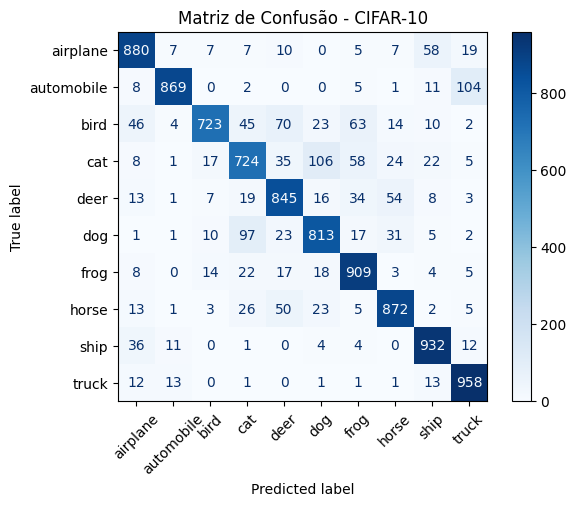

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.8513 - loss: 0.4739
Test Accuracy: 0.8525


In [15]:
# 10. Matriz de confusão
# Obter previsões no conjunto de teste
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# Rótulos reais
y_true = np.argmax(np.concatenate([y for x, y in test_ds], axis=0), axis=1)

# Matriz de confusão
cm = confusion_matrix(y_true, y_pred)
labels = ['airplane', 'automobile', 'bird', 'cat', 'deer',
          'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Matriz de Confusão - CIFAR-10')
plt.show()

loss, acc = model.evaluate(test_ds)
print(f"Test Accuracy: {acc:.4f}")